In [1]:
import pandas as pd 
df=pd.read_csv("churn_df_encoded.csv")

In [2]:
# Separate features and target variable
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

# Display the shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Check target distribution
print(y.value_counts())

Features shape: (7043, 30)
Target shape: (7043,)
Churn_Yes
False    5174
True     1869
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the shape of each dataset
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


In [21]:
print("Training set:")
print(y_train.value_counts(normalize=True))

print("\nTesting set:")
print(y_test.value_counts(normalize=True))

Training set:
Churn_Yes
False    0.734647
True     0.265353
Name: proportion, dtype: float64

Testing set:
Churn_Yes
False    0.734564
True     0.265436
Name: proportion, dtype: float64


In [22]:
from sklearn.linear_model import LogisticRegression

# Create the model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
# Predict the target values for the testing set
y_pred_lr = lr.predict(X_test)

# Display the first 10 predictions
print(y_pred_lr[:10])

[False  True False False False  True False False False False]


In [24]:
comparison = X_test.copy()

comparison["Actual"] = y_test.values
comparison["Predicted"] = y_pred_lr

comparison[["Actual", "Predicted"]].head(10)

,Actual,Predicted
437,False,False
2280,False,True
2235,False,False
4460,False,False
3761,False,False
5748,False,True
3568,False,False
2976,False,False
5928,False,False
1639,True,False


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
# Print results
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.8048
Precision: 0.6542
Recall   : 0.5615
F1-score : 0.6043

Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1035
        True       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [26]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [27]:
# Predict on the testing data
y_pred_dt = dt.predict(X_test)

# Display the first 10 predictions
print(y_pred_dt[:10])

[False  True False  True False False False False False False]


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.7260
Precision: 0.4838
Recall   : 0.4786
F1-score : 0.4812

Classification Report:
              precision    recall  f1-score   support

       False       0.81      0.82      0.81      1035
        True       0.48      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [9]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf = RandomForestClassifier(
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [10]:
# Predict on the testing set
y_pred_rf = rf.predict(X_test)

# Display the first 10 predictions
print(y_pred_rf[:10])

[False  True False False False False False False False False]


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7850
Precision: 0.6179
Recall   : 0.4973
F1-score : 0.5511

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1035
        True       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [12]:
import pandas as pd

# Create a DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 features
print(feature_importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.191149
1                           tenure    0.174795
2                   MonthlyCharges    0.169026
28  PaymentMethod_Electronic check    0.039095
10     InternetService_Fiber optic    0.037259
25               Contract_Two year    0.029864
13              OnlineSecurity_Yes    0.029774
4                      gender_Male    0.028501
26            PaperlessBilling_Yes    0.025097
19                 TechSupport_Yes    0.023192


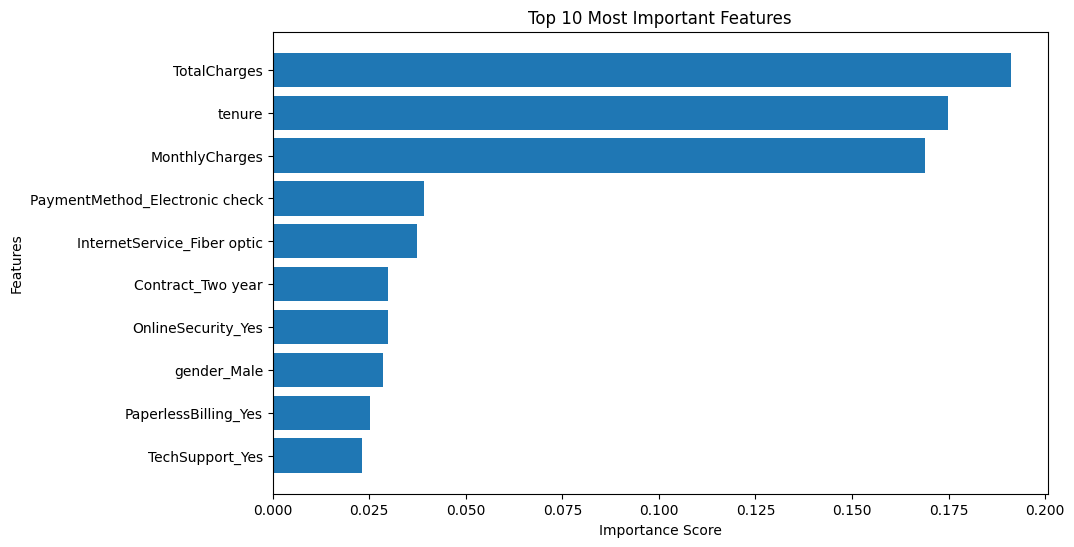

In [13]:
import matplotlib.pyplot as plt

# Select the 10 most important features
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

# Create the model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation F1:", grid_search.best_score_)

Best Parameters: {'C': 100}
Best Cross-validation F1: 0.5998483865431528


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
# Best Logistic Regression model after tuning
best_lr = LogisticRegression(
    C=100,
    max_iter=5000,
    random_state=42
)

best_lr.fit(X_train, y_train)

y_pred_best = best_lr.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.8013
Precision: 0.6478
Recall   : 0.5508
F1-score : 0.5954


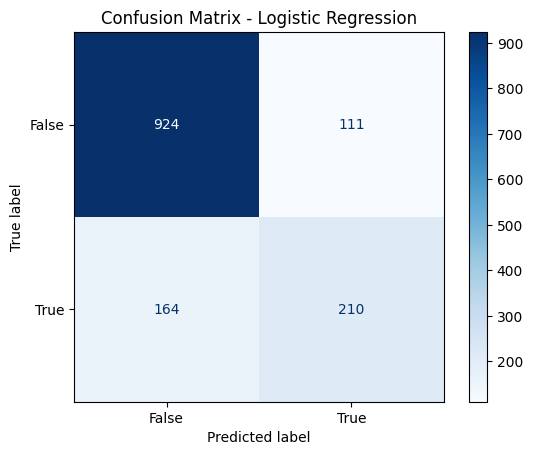

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Display the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

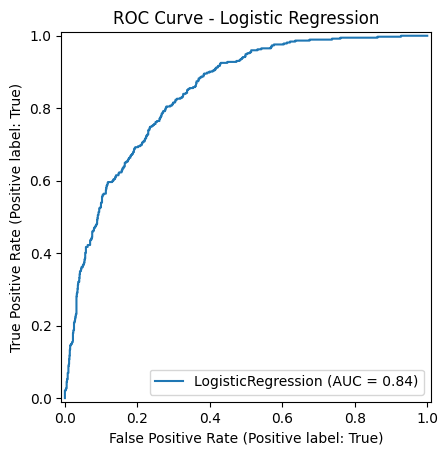

In [30]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Plot the ROC curve
RocCurveDisplay.from_estimator(
    lr,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [ ]:
import pandas as pd
# Create a DataFrame of coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

# Sort coefficients
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)
# Display the 10 most positive coefficients
print("Top 10 Positive Coefficients:")
print(coefficients.head(10))

print("\nTop 10 Negative Coefficients:")
print(coefficients.tail(10))

Top 10 Positive Coefficients:
                           Feature  Coefficient
10     InternetService_Fiber optic     0.742896
28  PaymentMethod_Electronic check     0.387787
26            PaperlessBilling_Yes     0.376456
9                MultipleLines_Yes     0.274968
23             StreamingMovies_Yes     0.204574
21                 StreamingTV_Yes     0.204150
8   MultipleLines_No phone service     0.164610
0                    SeniorCitizen     0.147470
29      PaymentMethod_Mailed check     0.080358
5                      Partner_Yes     0.024925

Top 10 Negative Coefficients:
                                 Feature  Coefficient
18       TechSupport_No internet service    -0.111778
16  DeviceProtection_No internet service    -0.111778
20       StreamingTV_No internet service    -0.111778
15                      OnlineBackup_Yes    -0.181573
6                         Dependents_Yes    -0.219680
19                       TechSupport_Yes    -0.389446
7                       PhoneServ